# Scary Stochastics, Week 3: Brownian Motion
## Notebook 3 of 3 — Outbreak Analysis

Also self-contained. Movie zombie outbreaks spread explosively; diffusion-driven outbreaks don't. This notebook checks that directly, maps where infections clustered, and shows the town's final outcome.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Zombie outbreak palette (extends the series palette with zombie green + cured steel blue)
PALETTE = {
    "red":    "#C8102E",  # candy red - patient zero marker
    "orange": "#E8741C",
    "rust":   "#B5451B",
    "purple": "#3B2145",
    "mustard":"#D9A404",
    "green":  "#6B8E23",  # zombie green - infected
    "blue":   "#4682B4",  # cured / steel blue - recovered
    "slate":  "#8C8C7A",  # susceptible - untouched humans
    "black":  "#1B1B1B",
    "cream":  "#FBF3E1",
}

STATE_NAMES = ["Susceptible", "Infected", "Recovered"]
STATE_COLORS = {"Susceptible": PALETTE["slate"], "Infected": PALETTE["green"], "Recovered": PALETTE["blue"]}

# Shared simulation constants
POP_SIZE = 180
TOWN_SIZE = 100.0
N_STEPS = 150
SIGMA = 1.5            # shambling step size (per-tick movement std)
CONTACT_RADIUS = 3.0
INFECTION_PROB = 0.15
RECOVERY_PROB = 0.02

plt.rcParams.update({
    "figure.facecolor": PALETTE["cream"],
    "axes.facecolor": PALETTE["cream"],
    "axes.edgecolor": PALETTE["black"],
    "text.color": PALETTE["black"],
    "axes.labelcolor": PALETTE["black"],
    "xtick.color": PALETTE["black"],
    "ytick.color": PALETTE["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

In [2]:
# A town of 180 people, each doing their own independent Brownian walk.
# States: 0 = Susceptible, 1 = Infected, 2 = Recovered ("cured")
positions = np.random.uniform(0, TOWN_SIZE, size=(POP_SIZE, 2))
state = np.zeros(POP_SIZE, dtype=int)

patient_zero = 0
positions[patient_zero] = [TOWN_SIZE / 2, TOWN_SIZE / 2]
state[patient_zero] = 1
origin = positions[patient_zero].copy()

position_history = np.zeros((N_STEPS + 1, POP_SIZE, 2))
state_history = np.zeros((N_STEPS + 1, POP_SIZE), dtype=int)
position_history[0] = positions
state_history[0] = state

infection_events = [(0.0, positions[patient_zero, 0], positions[patient_zero, 1])]
sir_counts = [(np.sum(state == 0), np.sum(state == 1), np.sum(state == 2))]

for t in range(1, N_STEPS + 1):
    positions = positions + np.random.normal(0, SIGMA, size=(POP_SIZE, 2))
    positions = np.clip(positions, 0, TOWN_SIZE)

    infected_idx = np.where(state == 1)[0]
    susceptible_idx = np.where(state == 0)[0]

    if len(infected_idx) > 0 and len(susceptible_idx) > 0:
        diff = positions[susceptible_idx][:, None, :] - positions[infected_idx][None, :, :]
        dists = np.sqrt((diff ** 2).sum(axis=2))
        near_zombie = dists.min(axis=1) < CONTACT_RADIUS
        roll = np.random.uniform(size=len(susceptible_idx)) < INFECTION_PROB
        newly_infected = susceptible_idx[near_zombie & roll]
        for idx in newly_infected:
            infection_events.append((float(t), positions[idx, 0], positions[idx, 1]))
        state[newly_infected] = 1

    if len(infected_idx) > 0:
        recover_roll = np.random.uniform(size=len(infected_idx)) < RECOVERY_PROB
        state[infected_idx[recover_roll]] = 2

    position_history[t] = positions
    state_history[t] = state
    sir_counts.append((np.sum(state == 0), np.sum(state == 1), np.sum(state == 2)))

sir_counts = np.array(sir_counts)
infection_events = pd.DataFrame(infection_events, columns=["Step", "X", "Y"])
sir_counts[:5]

array([[179,   1,   0],
       [179,   1,   0],
       [179,   1,   0],
       [179,   1,   0],
       [179,   1,   0]])

### Visual 5 — How fast does the outbreak frontier expand?

For a pure diffusion process, distance from the origin scales with √t, not with t itself — the classic 'zombies spread explosively' trope doesn't hold up here. The dashed reference curve is scaled to match the frontier's final distance, so the comparison is about *shape* (√t vs. the actual curve), not an exact derivation.

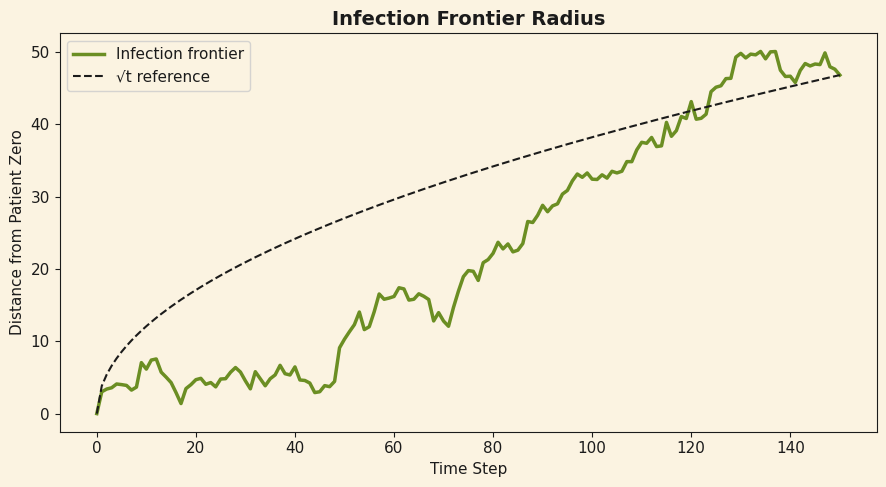

In [3]:
ever_infected = state_history != 0  # Infected or Recovered
frontier = np.array([
    np.max(np.linalg.norm(position_history[t][ever_infected[t]] - origin, axis=1))
    if ever_infected[t].any() else 0.0
    for t in range(N_STEPS + 1)
])

steps = np.arange(N_STEPS + 1)
sqrt_ref = frontier[-1] * np.sqrt(steps / N_STEPS)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, frontier, color=PALETTE["green"], linewidth=2.5, label="Infection frontier")
ax.plot(steps, sqrt_ref, color=PALETTE["black"], linestyle="--", linewidth=1.5,
        label="√t reference")
ax.set_xlabel("Time Step")
ax.set_ylabel("Distance from Patient Zero")
ax.set_title("Infection Frontier Radius")
ax.legend()
plt.tight_layout()
plt.savefig("05_frontier_radius.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Visual 6 — Where did infections cluster?

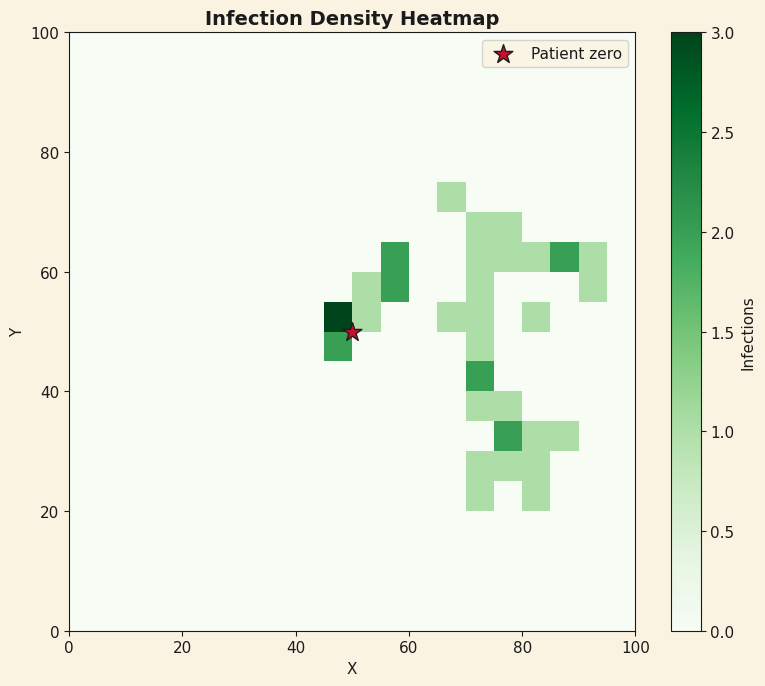

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
h = ax.hist2d(infection_events["X"], infection_events["Y"], bins=20,
              range=[[0, TOWN_SIZE], [0, TOWN_SIZE]], cmap="Greens")
ax.scatter(*origin, color=PALETTE["red"], marker="*", s=200,
           edgecolors=PALETTE["black"], linewidths=1, label="Patient zero", zorder=3)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Infection Density Heatmap")
ax.legend()
plt.colorbar(h[3], label="Infections")
plt.tight_layout()
plt.savefig("06_infection_heatmap.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Visual 7 — Who made it?

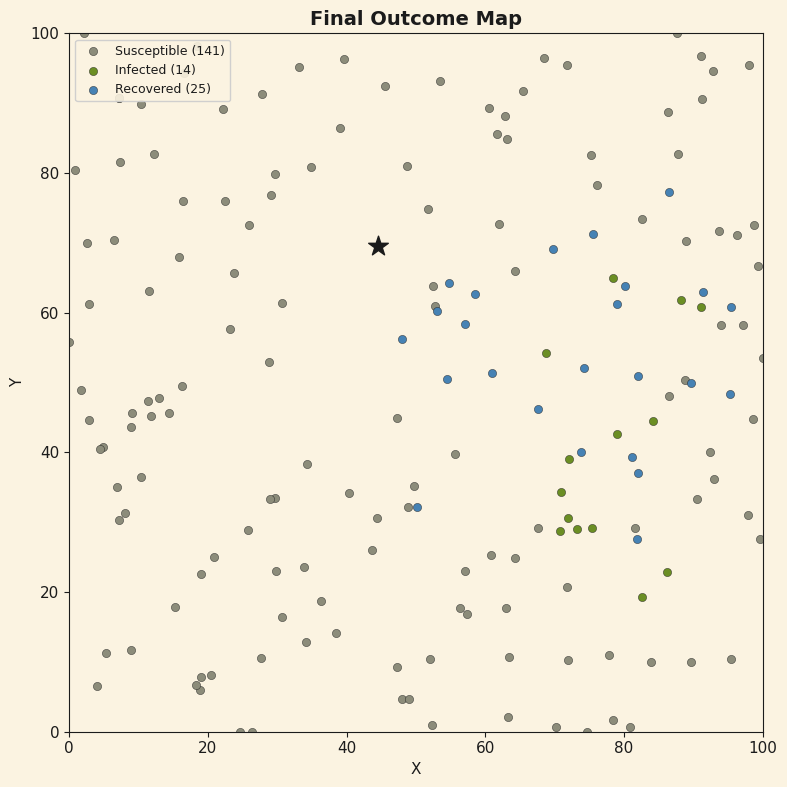

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
final_pos, final_state = position_history[-1], state_history[-1]
for i, name in enumerate(STATE_NAMES):
    mask = final_state == i
    ax.scatter(final_pos[mask, 0], final_pos[mask, 1], color=STATE_COLORS[name],
               s=35, label=f"{name} ({mask.sum()})", edgecolors=PALETTE["black"], linewidths=0.3)
ax.scatter(*position_history[-1, patient_zero], color=PALETTE["black"],
           marker="*", s=220, zorder=3)
ax.set_xlim(0, TOWN_SIZE); ax.set_ylim(0, TOWN_SIZE)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Final Outcome Map")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig("07_final_outcome.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Up next

Week 4 closes the loop back to Markov chains: Gibbs Sampling, using the same machinery from Week 1 to restore a noisy image.